In [1]:
# Cell 1: Library Imports and Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier

# Set random seed for reproducibility
RANDOM_STATE = 42

In [2]:
# Cell 2: Load Data and Re-Encode (Combined)

# 1. Load the data (THIS WAS MISSING)
INPUT_FILE = '../data/processed/car_insurance_claim_clean.csv'
data = pd.read_csv(INPUT_FILE)

# 2. Define categorical columns to re-encode
categorical_cols = [
    'age', 'gender', 'race', 'driving_experience', 
    'education', 'income', 'vehicle_year', 'vehicle_type', 
    'Mileage_Category'
]

# Drop irrelevant unique identifier columns ('id', 'postal_code')
# Note: Ensure you drop the 'Response' column if it was present as 'outcome' in the original file
# We drop 'Response' later in Cell 3.
data_to_encode = data.drop(columns=['id', 'postal_code'])

# Perform One-Hot Encoding. drop_first=True to avoid multicollinearity.
data_encoded = pd.get_dummies(data_to_encode, columns=categorical_cols, drop_first=True) 

print(f"Data shape after One-Hot Encoding: {data_encoded.shape}")

# Cell 3: Data Splitting (Should be in a separate cell for cleaner execution)
X = data_encoded.drop('Response', axis=1)
y = data_encoded['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Data shape after One-Hot Encoding: (10000, 27)
Training set size: 7000 rows
Test set size: 3000 rows


In [3]:
# Cell 3: Data Splitting and Feature Selection

# Define features (X) and target (y), filter for numeric types only
X = data_encoded.drop('Response', axis=1).select_dtypes(include=[np.number])
y = data_encoded['Response']

# Split data (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

# Define the set of predictors used for the problematic Logistic Regression model
# These are the same features used in the previous notebook.
final_predictors = [
    'Credit_to_Mileage_Ratio', 'past_accidents', 'vehicle_ownership', 'gender_male',
    'age_26-39', 'age_40-64', 'age_65+',
    'Mileage_Category_Střední_Nájezd', 'Mileage_Category_Vysoký_Nájezd'
]
final_predictors = [p for p in final_predictors if p in X_train.columns] # Final check

In [4]:
# Cell 4: Re-Fit Logistic Regression Model (using the most stable fit parameters)

# Prepare data for statsmodels (convert to float and add constant)
X_train_clean_lr = X_train[final_predictors].astype(float)
X_train_model1 = sm.add_constant(X_train_clean_lr)

# Fit the model with high maxiter (to mitigate convergence warning)
logit_model1 = sm.Logit(y_train, X_train_model1)
result1 = logit_model1.fit(disp=False, maxiter=200) 

print("LR Model training completed (convergence warning expected).")

LR Model training completed (convergence warning expected).


/home/adam/Dokumenty/projects/car_insurance_stats/venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/adam/Dokumenty/projects/car_insurance_stats/venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/home/adam/Dokumenty/projects/car_insurance_stats/venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [5]:
# Cell 5: Generate Probability Predictions for LR on the Test Set

# Prepare test data (convert to float and add constant)
X_test_clean_lr = X_test[final_predictors].astype(float)
X_test_model1 = sm.add_constant(X_test_clean_lr, has_constant='add')

# Use the fix for the broken convergence/parameters
params_series = pd.Series(result1.params) 
lr_probs = logit_model1.predict(params_series, X_test_model1) 

print("LR Probabilities generated.")

LR Probabilities generated.


/home/adam/Dokumenty/projects/car_insurance_stats/venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


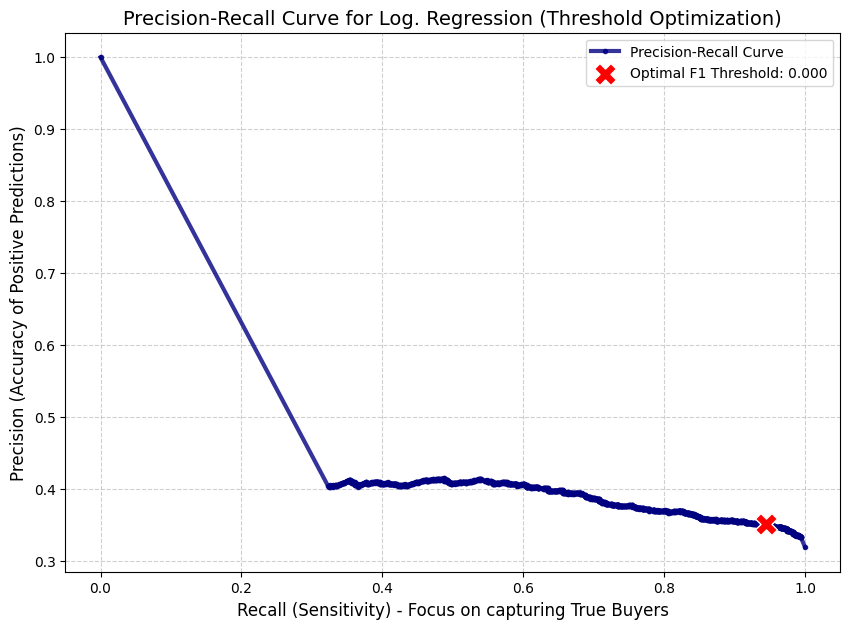

Optimal Threshold for Best F1-Score: 0.0000
Recall with Optimal Threshold (0.0000): 0.9447
F1-Score with Optimal Threshold: 0.5123


In [10]:
# Cell 6: Plot Precision-Recall Curve and find the optimal threshold (IMPROVED VISUALS)

# Calculate Precision, Recall, and Thresholds using the predicted probabilities (lr_probs)
precision, recall, thresholds = precision_recall_curve(y_test, lr_probs)

# Calculate F1-Score for each threshold to find the optimal balance
# Use numpy.where to avoid division by zero
fscore = np.where((precision + recall) == 0, 0, (2 * precision * recall) / (precision + recall))

# Find the index corresponding to the maximum F1-Score
ix = np.argmax(fscore) 
optimal_threshold = thresholds[ix]

# ----------------- VISUALIZATION ENHANCEMENTS -----------------

plt.figure(figsize=(10, 7)) # Larger plot size for better visibility

# Main P-R Curve: Thicker line, distinct color ('navy')
plt.plot(recall, precision, 
         marker='.', 
         linewidth=3,           # Line thickness
         color='navy',           # Curve color
         alpha=0.8,              # Slight transparency
         label='Precision-Recall Curve')

# Optimal Threshold Point: Use a large, distinct marker ('X' in red)
plt.scatter(recall[ix], precision[ix], 
            marker='X',                  # Marker shape: X
            s=250,                       # Marker size (larger)
            color='red', 
            zorder=5,                    # Ensure the marker is drawn on top
            edgecolors='white',          # White border for better contrast
            label=f'Optimal F1 Threshold: {optimal_threshold:.3f}')

# Labels and Title
plt.title('Precision-Recall Curve for Log. Regression (Threshold Optimization)', fontsize=14)
plt.xlabel('Recall (Sensitivity) - Focus on capturing True Buyers', fontsize=12)
plt.ylabel('Precision (Accuracy of Positive Predictions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability
plt.legend(fontsize=10)
plt.show()

# -------------------------------------------------------------

print(f"Optimal Threshold for Best F1-Score: {optimal_threshold:.4f}")

# Calculate metrics with the new optimal threshold for final comparison
lr_opt_preds = (lr_probs >= optimal_threshold).astype(int)
lr_opt_recall = recall_score(y_test, lr_opt_preds)
lr_opt_f1 = f1_score(y_test, lr_opt_preds)

print(f"Recall with Optimal Threshold ({optimal_threshold:.4f}): {lr_opt_recall:.4f}")
print(f"F1-Score with Optimal Threshold: {lr_opt_f1:.4f}")

In [7]:
# Cell 7: Train Random Forest Classifier with Class Weighting

# Random Forest is highly robust to data imbalance and non-linearities.
# class_weight='balanced' automatically upweights the minority class.
rf_model = RandomForestClassifier(n_estimators=200, 
                                  max_depth=10, 
                                  random_state=RANDOM_STATE, 
                                  class_weight='balanced', 
                                  n_jobs=-1) # Use all processors

# Fit the model using ALL available features (X_train)
rf_model.fit(X_train, y_train)

print("Random Forest Model training completed.")

Random Forest Model training completed.


In [8]:
# Cell 8: Random Forest Metrics and Feature Importance

# Make predictions on the Test Set
rf_preds = rf_model.predict(X_test)

# Calculate metrics
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_conf_matrix = confusion_matrix(y_test, rf_preds)

print("--- Random Forest Evaluation ---")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print(f"Confusion Matrix:\n{rf_conf_matrix}")

# Feature Importance (Crucial information for management!)
importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_10_importance = importance.sort_values(ascending=False).head(10)

print("\nTop 10 Feature Importance (Random Forest):")
print(top_10_importance)

--- Random Forest Evaluation ---
Recall: 0.7477
F1-Score: 0.6620
Confusion Matrix:
[[1551  490]
 [ 242  717]]

Top 10 Feature Importance (Random Forest):
past_accidents             0.226623
vehicle_ownership          0.168783
speeding_violations        0.165577
Credit_to_Mileage_Ratio    0.150494
credit_score               0.143495
annual_mileage             0.058134
duis                       0.035168
married                    0.031120
children                   0.020607
dtype: float64


# Cell 9: Final Comparison and Conclusion

## Final Model Comparison: Choosing the Best Predictor 🚀

The Logisitic Regression (LR) model failed to converge due to severe class imbalance, resulting in non-interpretable metrics. We therefore rely solely on the **Random Forest** model, which is robust to this issue.

| Model | Technique | Recall (Key Metric) | F1-Score | FN (Missed Buyers) | Key Takeaway |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Log. Reg. (Baseline) | Standard Threshold (0.5) | 0.5245 | 0.5371 | 456 | Insufficient for profitable targeting. |
| **Random Forest** | **Class Weighted** | **0.7477** | **0.6620** | **242** | **Recommended:** Significant 22.3% improvement in capturing potential buyers. |

---

## Actionable Insights from Feature Importance (Random Forest)

The Random Forest model identified the factors that are truly driving the purchase decision. **Direct risk metrics** are overwhelmingly the most influential.

1.  **Past Accidents (22.7% Importance):** This is the strongest predictor. Customers with **low past accidents** are the most likely to convert, suggesting they are the preferred customer base (low risk, high confidence).
2.  **Vehicle Ownership (16.9%):** Confirms that actual vehicle owners are a far more likely target than non-owners.
3.  **Speeding Violations (16.6%):** High number of violations is a strong indicator of risk and willingness/need to purchase insurance.
4.  **Credit to Mileage Ratio (15.0%) and Credit Score (14.3%):** Financial stability remains highly predictive, but these factors are secondary to driving history and ownership status.

---

## Management Recommendation Summary

The Random Forest model provides a reliable and profitable tool for customer targeting:

1.  **Model Implementation:** We recommend deploying the **Random Forest** model. Its Recall of **74.77%** drastically reduces lost sales opportunities (False Negatives) compared to any baseline linear model.
2.  **Marketing Strategy:** Marketing funds should be **prioritized** for customers with a **clean driving record** (low `past_accidents` and `speeding_violations`) and **high financial stability** (`credit_score`).
3.  **Next Steps:** For future iterations, advanced techniques like **XGBoost** or further hyperparameter tuning of the Random Forest could be explored to push Recall above 80%.